In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
sns.set_theme()


In [22]:
data=pd.read_csv('Assignment2.data', sep='\t')
data['x']=list(range(226))
data.head()

,SpringPos,StockPrice,x
0,2.27,3.48,0
1,6.38,2.99,1
2,8.61,5.86,2
3,8.65,1.79,3
4,13.17,3.47,4


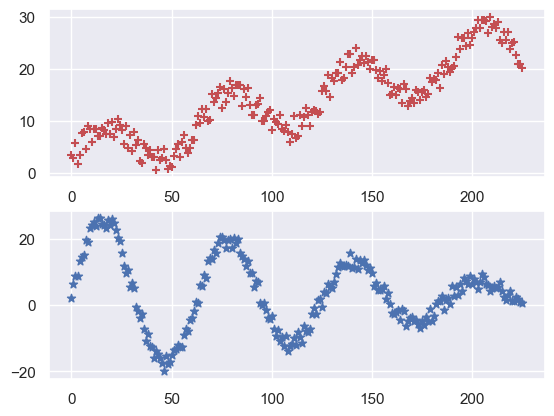

In [23]:
fig, axes=plt.subplots(2, 1)
axes[0].scatter(x=data['x'], y=data['StockPrice'], marker='+', color='r')
axes[1].scatter(x=data['x'], y=data['SpringPos'], marker='*', color='b')

In [24]:
def sse(y_true, y_pred):
    return np.sum((y_true-y_pred)**2)

# Task 1 (Part 3)

Min SSE: 7644.000000
Corresponding Theta: 5
Corresponding slope: 0.087489


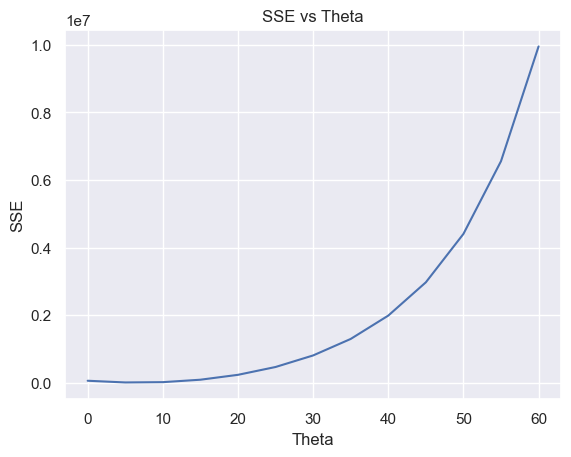

In [25]:
thetas=np.array(list(range(0, 61, 5)))
tan_thetas=np.tan(thetas*np.pi/180)
sses=np.array([0]*tan_thetas.shape[0])
for i, tan_theta in enumerate(tan_thetas):
    predictions=data['x']*tan_theta
    sses[i]=sse(data['StockPrice'], predictions)

i=sses.argmin()
print('Min SSE: %f'%sses[i])
print('Corresponding Theta: %d'%thetas[i])
print('Corresponding slope: %f'%tan_thetas[i])
plt.plot(thetas, sses)
plt.xlabel('Theta')
plt.ylabel('SSE')
plt.title('SSE vs Theta');

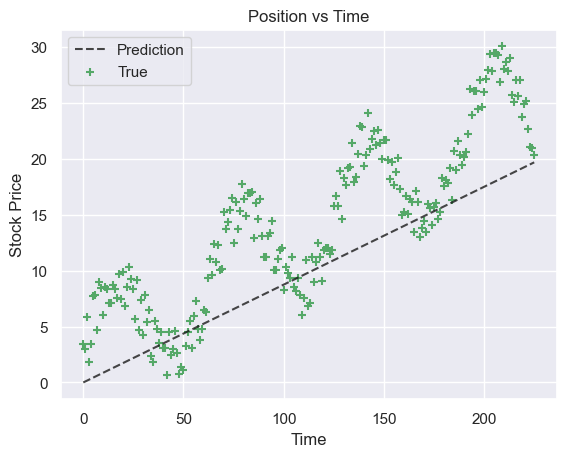

In [26]:
predictions=data['x']*0.087489
plt.plot(data['x'], predictions, linestyle='--', color='k', alpha=0.8)
plt.scatter(x=data['x'], y=data['StockPrice'], marker='+', color='g')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.title('Position vs Time')
plt.legend(['Prediction', 'True']);

# Task 2

Model being implemented: $y=m_1\sin(x)+m_2x+c$ 

In [27]:
y=data['StockPrice']
X=data['x'].to_frame()
X2=X.copy()
# X2['x_scaled']=X*0.09774
X2['x_scaled']=X*0.1
X2['sinx_scaled']=np.sin(X2['x_scaled'])

#### Interpolation

In [28]:
def train_val_test_split(X, y, val_size, test_size):
    X_train, X_temp, y_train, y_temp=train_test_split(X, y, test_size=val_size+test_size, random_state=0)
    X_val, X_test, y_val, y_test=train_test_split(X_temp, y_temp, test_size=test_size/(test_size+val_size), random_state=3)
    return X_train, X_val, X_test, y_train, y_val, y_test

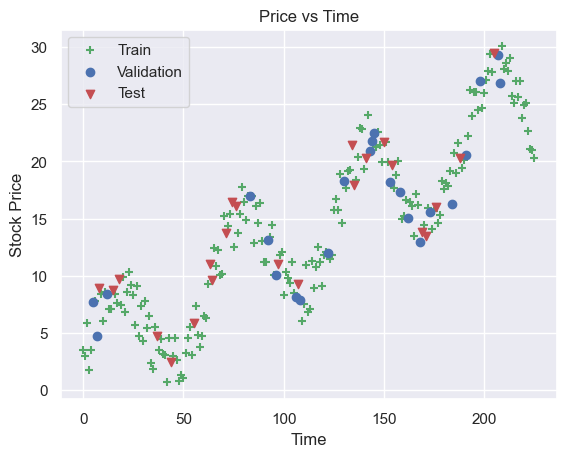

In [29]:
X_train, X_val, X_test, y_train, y_val, y_test=train_val_test_split(X2, y, val_size=0.1, test_size=0.1)
plt.scatter(x=X_train['x'], y=y_train, marker='+', color='g')
plt.scatter(x=X_val['x'], y=y_val, marker='o', color='b')
plt.scatter(x=X_test['x'], y=y_test, marker='v', color='r')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.title('Price vs Time')
plt.legend(['Train', 'Validation', 'Test']);

In [30]:
reg_f=LinearRegression()
reg_f.fit(X_train.drop(['x'], axis=1), y_train)
reg_f.coef_, reg_f.intercept_

(array([1.00356939, 4.98385402]), np.float64(2.4778523127378733))

In [31]:
predictions=reg_f.predict(X_train.drop(['x'], axis=1))
print('SSE Training: %f'%sse(y_train, predictions))
predictions=reg_f.predict(X_val.drop(['x'], axis=1))
print('SSE Validation: %f'%sse(y_val, predictions))
predictions=reg_f.predict(X_test.drop(['x'], axis=1))
print('SSE Test: %f'%sse(y_test, predictions))

SSE Training: 399.923344
SSE Validation: 39.440503
SSE Test: 35.545128


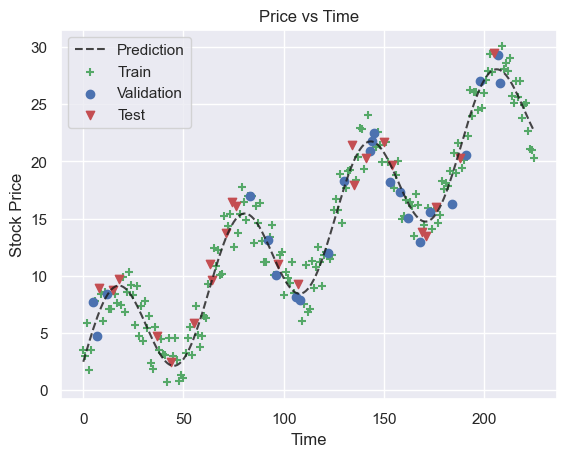

In [32]:
predictions=reg_f.predict(X2.drop(['x'], axis=1))
plt.plot(X2['x'], predictions, linestyle='--', color='k', alpha=0.8)
plt.scatter(x=X_train['x'], y=y_train, marker='+', color='g')
plt.scatter(x=X_val['x'], y=y_val, marker='o', color='b')
plt.scatter(x=X_test['x'], y=y_test, marker='v', color='r')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.title('Price vs Time')
plt.legend(['Prediction', 'Train', 'Validation', 'Test']);

#### Extrapolation

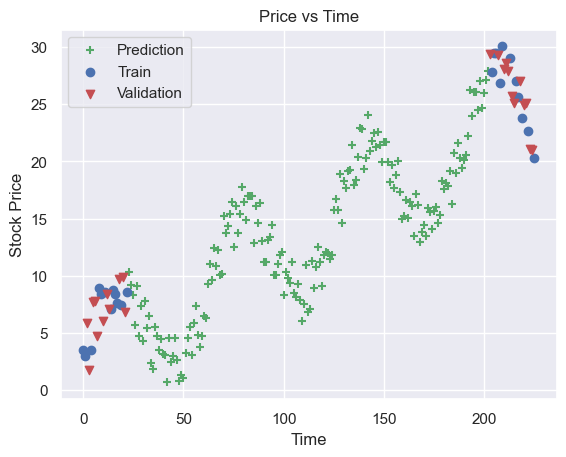

In [33]:
q10=X2['x'].quantile(0.1)
q90=X2['x'].quantile(0.9)
idx=X2['x'].between(left=q10, right=q90, inclusive='neither')
X_train, y_train=X2.loc[idx, :], y[idx]
X_val, X_test, y_val, y_test=train_test_split(X2.loc[~idx, :], y[~idx], test_size=0.5, random_state=10)
plt.scatter(x=X_train['x'], y=y_train, marker='+', color='g')
plt.scatter(x=X_val['x'], y=y_val, marker='o', color='b')
plt.scatter(x=X_test['x'], y=y_test, marker='v', color='r')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.title('Price vs Time')
plt.legend(['Prediction', 'Train', 'Validation', 'Test']);

In [34]:
reg_g=LinearRegression()
reg_g.fit(X_train.drop(['x'], axis=1), y_train)
reg_g.coef_, reg_g.intercept_

(array([0.96350563, 5.05581294]), np.float64(2.9478794156709736))

In [35]:
predictions=reg_g.predict(X_train.drop(['x'], axis=1))
print('SSE Training: %f'%sse(y_train, predictions))
predictions=reg_g.predict(X_val.drop(['x'], axis=1))
print('SSE Validation: %f'%sse(y_val, predictions))
predictions=reg_g.predict(X_test.drop(['x'], axis=1))
print('SSE Test: %f'%sse(y_test, predictions))

SSE Training: 370.915652
SSE Validation: 47.081760
SSE Test: 60.835492


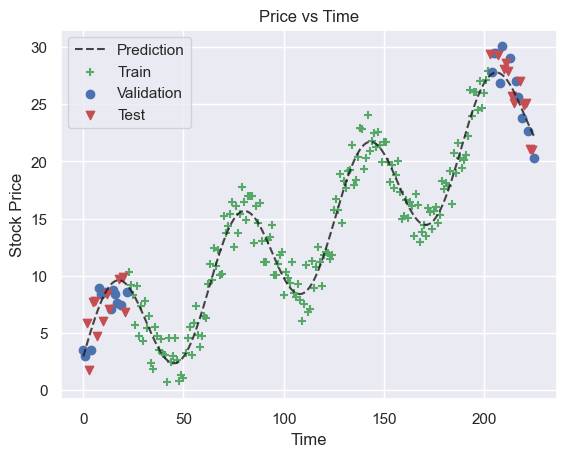

In [36]:
predictions=reg_g.predict(X2.drop(['x'], axis=1))
plt.plot(X2['x'], predictions, linestyle='--', color='k', alpha=0.8)
plt.scatter(x=X_train['x'], y=y_train, marker='+', color='g')
plt.scatter(x=X_val['x'], y=y_val, marker='o', color='b')
plt.scatter(x=X_test['x'], y=y_test, marker='v', color='r')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.title('Price vs Time')
plt.legend(['Prediction', 'Train', 'Validation', 'Test']);

# Task 3

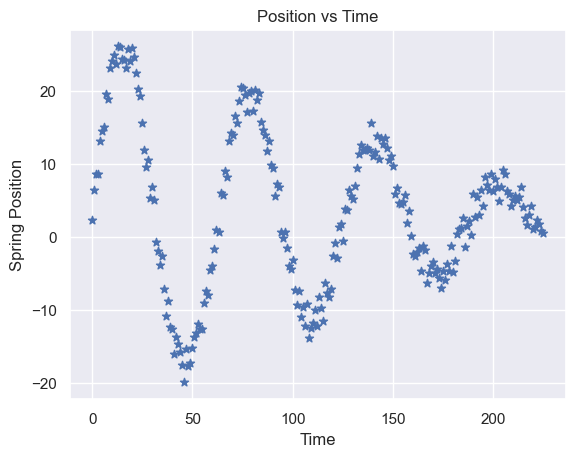

In [37]:
plt.scatter(x=data['x'], y=data['SpringPos'], marker='*', color='b');
plt.xlabel('Time')
plt.ylabel('Spring Position')
plt.title('Position vs Time');

From the visualization above, we can see that the curve is sinusoidal. It also seems to have an equal time period of oscillation. From the graph it is visible that the curve has completed three and a half oscillations. Since the period of the sin curve is $2\pi$, $3\frac{1}{2}$ oscillations correspond to $7\pi$ units. In order for the our estimated sin curve to behave like the original curve, our data has to be scaled appropriately, this can be done by scaling our data by a factor of $\frac{7\pi}{225} \approx 0.1$ because the maximum of our data i.e. 225 will correpond to $7\pi$ in the transformed variable.

In [38]:
y=data['SpringPos']
X=data['x'].to_frame()
X2=X.copy()
# X2['x_scaled']=X*0.09774
X2['x_scaled']=X*0.1
X2['sinx_scaled']=np.sin(X2['x_scaled'])

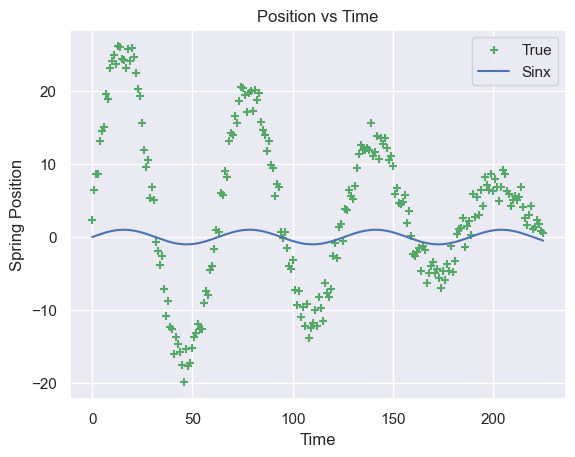

In [39]:
plt.scatter(x=data['x'], y=data['SpringPos'], marker='+', color='g');
plt.plot(X2['x'], X2['sinx_scaled'], linestyle='-', color='b')
plt.xlabel('Time')
plt.ylabel('Spring Position')
plt.title('Position vs Time')
plt.legend(['True', 'Sinx']);

From the above graph, we can observe that after scaling, we are approximately able to capture the behaviour of the curve meaning that it peaks where our true data peaks and it dips where our true data dips. Now the focus will be to appropriately scale this transformed feature so that it corresponds to the true curve.

#### Mathematical Model
1) $y=m_1\sin(x_{trans})+c_1$

    In this model we hypothesize the spring position to be a linear function of $\sin(x_{trans})$ where $x_{trans}$ is the scaled version of $x$, i.e. $x_{trans}=0.1x$. But the graph tells us that as $x$ or $x_{trans}$ increases, the amplitude of the sin curve reduces. So, the scaling of the sin curve is not constant with respect to $x_{trans}$. Hence, this model may not be a good model. <br/><br/><br/>

2) $y=m_1 \ast amp(x_{trans}) \ast \sin(x_{trans})+c_1$ <br/>
    where $amp(x_{trans})=m_2x_{trans}+c_2$ <br/><br/>
    In this model we hypothesize the spring position to be a linear function of $amp(x_{trans}) \ast \sin(x_{trans})$. Here $amp(x_{trans})$ is another linear function of $x_{trans}$ that represents the amplitude of the sin curve given $x_{trans}$, and can be thought of as the scaling factor which gets multiplied to $\sin(x_{trans})$. We expect $amp(x_{trans})$ to be a decreasing function beacause the scaling factor of the sin curve should reduce as $x_{trans}$ increases. This model also takes care of the problem faced by the first model as it introduces a dependency of the scaling factor on $x_{trans}$ which is precisely $amp(x_{trans})$.

    Expanding the equation we get :
    $y=m_1m_2x_{trans}\sin(x_{trans})+m_1c_2\sin(x_{trans})+c_1$ <br/>
    Which can be re-written as : 
    $y=\beta_1x_{trans}\sin(x_{trans})+\beta_2\sin(x_{trans})+c_1$ <br/>
    where $\beta_1=m_1m_2$ and $\beta_2=m_1c_2$ <br/>
    $\beta_1$, $\beta_2$, and $c_1$ can be found by running a Linear Regression model on the data where the two features are $x_{trans}\sin(x_{trans})$ and $\sin(x_{trans})$. <br/><br/>
    
The rest of the notebook runs a Linear Regression model according to the second model discussed above.

In [40]:
X3=X2.copy()
X3['xs_sinxs']=X3['x_scaled']*X3['sinx_scaled']

In [41]:
reg_c=LinearRegression()
reg_c.fit(X3.drop(['x', 'x_scaled'], axis=1), y)
reg_c.coef_, reg_c.intercept_

(array([24.8812691, -0.9971555]), np.float64(2.5719094020501503))

In [42]:
predictions=reg_c.predict(X3.drop(['x', 'x_scaled'], axis=1))
print('SSE: %f'%sse(y, predictions))

SSE: 464.520080


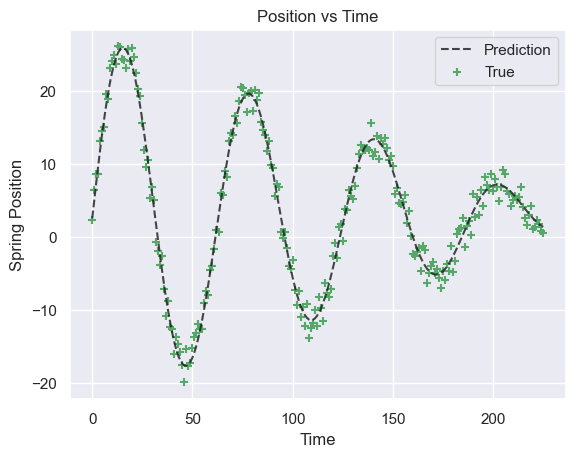

In [43]:
plt.plot(X3['x'], predictions, linestyle='--', color='k', alpha=0.8)
plt.scatter(x=X3['x'], y=y, marker='+', color='g')
plt.xlabel('Time')
plt.ylabel('Spring Position')
plt.title('Position vs Time')
plt.legend(['Prediction', 'True']);

#### Interpolation

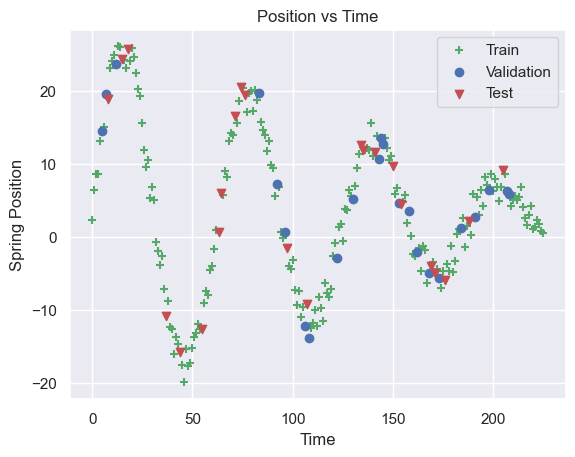

In [44]:
X_train, X_val, X_test, y_train, y_val, y_test=train_val_test_split(X3, y, val_size=0.1, test_size=0.1)
plt.scatter(x=X_train['x'], y=y_train, marker='+', color='g')
plt.scatter(x=X_val['x'], y=y_val, marker='o', color='b')
plt.scatter(x=X_test['x'], y=y_test, marker='v', color='r')
plt.xlabel('Time')
plt.ylabel('Spring Position')
plt.title('Position vs Time')
plt.legend(['Train', 'Validation', 'Test']);

In [45]:
reg_d=LinearRegression()
reg_d.fit(X_train.drop(['x', 'x_scaled'], axis=1), y_train)
reg_d.coef_, reg_d.intercept_

(array([24.78326563, -0.99491835]), np.float64(2.597844088489186))

In [46]:
predictions=reg_d.predict(X_train.drop(['x', 'x_scaled'], axis=1))
print('SSE Training: %f'%sse(y_train, predictions))
predictions=reg_d.predict(X_val.drop(['x', 'x_scaled'], axis=1))
print('SSE Validation: %f'%sse(y_val, predictions))
predictions=reg_d.predict(X_test.drop(['x', 'x_scaled'], axis=1))
print('SSE Test: %f'%sse(y_test, predictions))

SSE Training: 377.943491
SSE Validation: 43.761315
SSE Test: 43.510571


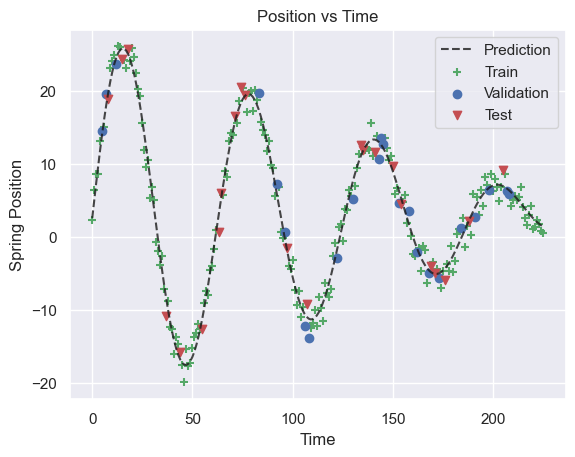

In [47]:
predictions=reg_d.predict(X3.drop(['x', 'x_scaled'], axis=1))
plt.plot(X3['x'], predictions, linestyle='--', color='k', alpha=0.8)
plt.scatter(x=X_train['x'], y=y_train, marker='+', color='g')
plt.scatter(x=X_val['x'], y=y_val, marker='o', color='b')
plt.scatter(x=X_test['x'], y=y_test, marker='v', color='r')
plt.xlabel('Time')
plt.ylabel('Spring Position')
plt.title('Position vs Time')
plt.legend(['Prediction', 'Train', 'Validation', 'Test']);

#### Extrapolation

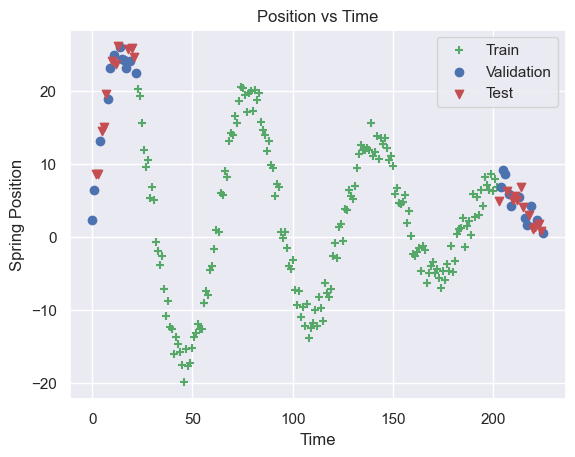

In [48]:
q10=X3['x'].quantile(0.1)
q90=X3['x'].quantile(0.9)
idx=X3['x'].between(left=q10, right=q90, inclusive='neither')
X_train, y_train=X3.loc[idx, :], y[idx]
X_val, X_test, y_val, y_test=train_test_split(X3.loc[~idx, :], y[~idx], test_size=0.5, random_state=10)
plt.scatter(x=X_train['x'], y=y_train, marker='+', color='g')
plt.scatter(x=X_val['x'], y=y_val, marker='o', color='b')
plt.scatter(x=X_test['x'], y=y_test, marker='v', color='r')
plt.xlabel('Time')
plt.ylabel('Spring Position')
plt.title('Position vs Time')
plt.legend(['Train', 'Validation', 'Test']);


In [49]:
reg_e=LinearRegression()
reg_e.fit(X_train.drop(['x', 'x_scaled'], axis=1), y_train)
reg_e.coef_, reg_e.intercept_

(array([24.5819605 , -0.97563354]), np.float64(2.547630399798971))

In [50]:
predictions=reg_e.predict(X_train.drop(['x', 'x_scaled'], axis=1))
print('SSE Training: %f'%sse(y_train, predictions))
predictions=reg_e.predict(X_val.drop(['x', 'x_scaled'], axis=1))
print('SSE Validation: %f'%sse(y_val, predictions))
predictions=reg_e.predict(X_test.drop(['x', 'x_scaled'], axis=1))
print('SSE Test: %f'%sse(y_test, predictions))

SSE Training: 384.585859
SSE Validation: 41.689560
SSE Test: 40.929021


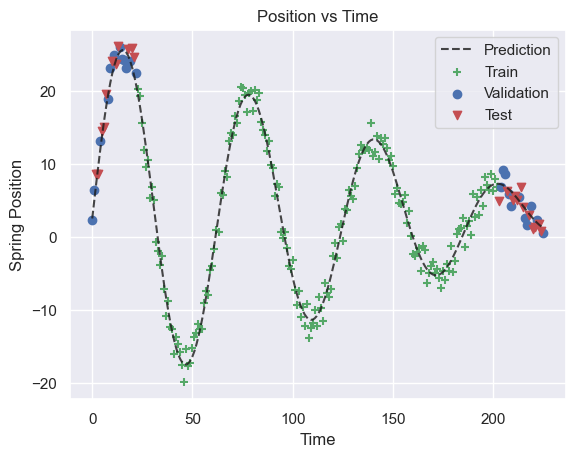

In [51]:
predictions=reg_e.predict(X3.drop(['x', 'x_scaled'], axis=1))
plt.plot(X3['x'], predictions, linestyle='--', color='k', alpha=0.8)
plt.scatter(x=X_train['x'], y=y_train, marker='+', color='g')
plt.scatter(x=X_val['x'], y=y_val, marker='o', color='b')
plt.scatter(x=X_test['x'], y=y_test, marker='v', color='r')
plt.xlabel('Time')
plt.ylabel('Spring Position')
plt.title('Position vs Time')
plt.legend(['Prediction', 'Train', 'Validation', 'Test']);